# Evaluations on the best defended model

In [1]:
pip install ultralytics torch torchvision numpy opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


## Imports And Config

In [2]:
import os, shutil, random, yaml, torch, cv2, gc
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# PATHS
DEFENDED_MODEL_PATH = "/kaggle/input/models/pawanpauljay/pgd-defended-85-epochs/pytorch/default/1/model.pt"
BASELINE_MODEL_PATH = "yolo26n-obb.pt"

TRAIN_IMAGES_DIR = "/kaggle/input/datasets/aayushbhargav/defensedataset/images/train"
TRAIN_LABELS_DIR = "/kaggle/input/datasets/aayushbhargav/defensedataset/labels/train"

WORK_DIR = "/kaggle/working/final_eval"
IMG_SIZE = 1024
NUM_IMAGES = 50

EPSILONS = [0.01, 0.02, 0.04, 0.08]
PGD_ITERS = 10
PGD_ALPHA_MULT = 0.25

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CLASS_NAMES = {
    0:'plane', 1:'ship', 2:'storage tank', 3:'baseball diamond', 4:'tennis court',
    5:'basketball court', 6:'ground track field', 7:'harbor', 8:'bridge',
    9:'large vehicle', 10:'small vehicle', 11:'helicopter', 12:'roundabout',
    13:'soccer ball field', 14:'swimming pool', 15:'container crane'
}
NAME_TO_IDX = {v:k for k,v in CLASS_NAMES.items()}

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Helper Functions

In [3]:
def filter_with_labels(image_list, label_dir):
    valid = []
    for f in image_list:
        lbl = f.rsplit('.',1)[0] + ".txt"
        if os.path.exists(os.path.join(label_dir, lbl)):
            valid.append(f)
    return valid


def get_sample():
    # Only use clean_ images from the defense dataset (what the model was trained on)
    all_imgs = [f for f in os.listdir(TRAIN_IMAGES_DIR) if f.startswith("clean_")]
    all_imgs = filter_with_labels(all_imgs, TRAIN_LABELS_DIR)
    print(f"Valid clean images found: {len(all_imgs)}")
    return random.sample(all_imgs, min(NUM_IMAGES, len(all_imgs)))


def prepare(images, img_dir, lbl_dir, out):
    os.makedirs(out+"/images", exist_ok=True)
    os.makedirs(out+"/labels", exist_ok=True)

    for f in images:
        img = cv2.imread(os.path.join(img_dir, f))
        if img is None: continue

        cv2.imwrite(out+"/images/"+f, cv2.resize(img,(IMG_SIZE,IMG_SIZE)))

        lbl_name = f.rsplit('.',1)[0] + ".txt"
        src_lbl  = os.path.join(lbl_dir, lbl_name)
        dst_lbl  = out+"/labels/"+lbl_name

        if os.path.exists(src_lbl):
            shutil.copy(src_lbl, dst_lbl)


def make_yaml(base_dir, name):
    yaml_path = base_dir + f"/{name}.yaml"
    with open(yaml_path, "w") as f:
        yaml.dump({
            "path"  : os.path.abspath(base_dir+"/"+name),
            "train" : "images",
            "val"   : "images",
            "nc"    : len(CLASS_NAMES),
            "names" : list(CLASS_NAMES.values())
        }, f)
    return yaml_path


def calc_f1(p, r):
    return 2*p*r / (p+r+1e-6)

## PGD ATTACK

In [4]:
def pgd_attack(model, path, eps):
    raw = model.model.to(DEVICE)
    raw.train()

    img = cv2.imread(path)
    if img is None:
        print(f"⚠️ Could not read: {path}")
        return

    img  = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    orig = torch.tensor(img).permute(2,0,1).unsqueeze(0).float().to(DEVICE) / 255
    adv  = orig.clone()

    for _ in range(PGD_ITERS):
        adv.requires_grad_(True)
        out = raw(adv)

        loss = 0
        def collect(x):
            nonlocal loss
            if isinstance(x, torch.Tensor) and x.requires_grad:
                loss += x.sum()
            elif isinstance(x, (list, tuple)):
                for i in x: collect(i)
            elif isinstance(x, dict):
                for v in x.values(): collect(v)

        collect(out)
        raw.zero_grad()
        loss.backward()

        with torch.no_grad():
            adv = adv + (eps * PGD_ALPHA_MULT) * adv.grad.sign()
            eta = torch.clamp(adv - orig, -eps, eps)
            adv = torch.clamp(orig + eta, 0, 1)

    img = (adv.squeeze().permute(1,2,0).cpu().numpy()*255).astype(np.uint8)
    cv2.imwrite(path, img)

## Evaluate and Plot

In [5]:
def evaluate(images):
    base_dir  = f"{WORK_DIR}/eval"
    clean_dir = base_dir + "/clean"

    # Prepare clean images
    prepare(images, TRAIN_IMAGES_DIR, TRAIN_LABELS_DIR, clean_dir)
    yaml_clean = make_yaml(base_dir, "clean")

    # Evaluate both models on clean images
    c_base = base_eval.val(data=yaml_clean, task="obb", device=DEVICE, plots=False)
    c_def  = def_eval.val(data=yaml_clean,  task="obb", device=DEVICE, plots=False)

    print(f"\nClean — Baseline mAP50: {c_base.box.map50:.3f} | Defended mAP50: {c_def.box.map50:.3f}\n")

    metrics = {
        "map50_base":[], "map50_def":[],
        "map95_base":[], "map95_def":[],
        "p_base":[],     "p_def":[],
        "r_base":[],     "r_def":[],
        "f1_base":[],    "f1_def":[]
    }

    # For each epsilon, generate adversarial images and evaluate
    for eps in EPSILONS:
        print(f"Running PGD attack with epsilon={eps}...")
        adv_dir = base_dir + f"/adv_{eps}"
        prepare(images, TRAIN_IMAGES_DIR, TRAIN_LABELS_DIR, adv_dir)

        for f in images:
            pgd_attack(base_attack, adv_dir+"/images/"+f, eps)

        yaml_adv = make_yaml(base_dir, f"adv_{eps}")

        m1 = base_eval.val(data=yaml_adv, task="obb", device=DEVICE, plots=False)
        m2 = def_eval.val(data=yaml_adv,  task="obb", device=DEVICE, plots=False)

        metrics["map50_base"].append(m1.box.map50)
        metrics["map50_def"].append(m2.box.map50)
        metrics["map95_base"].append(m1.box.map)
        metrics["map95_def"].append(m2.box.map)
        metrics["p_base"].append(m1.box.mp)
        metrics["p_def"].append(m2.box.mp)
        metrics["r_base"].append(m1.box.mr)
        metrics["r_def"].append(m2.box.mr)
        metrics["f1_base"].append(calc_f1(m1.box.mp, m1.box.mr))
        metrics["f1_def"].append(calc_f1(m2.box.mp, m2.box.mr))

        print(f"  Baseline mAP50: {m1.box.map50:.3f} | Defended mAP50: {m2.box.map50:.3f}")

    # Plot results
    def get_clean_vals(metric):
        if metric == "map50":
            return float(c_base.box.map50), float(c_def.box.map50)
        elif metric == "map95":
            return float(c_base.box.map), float(c_def.box.map)
        elif metric == "p":
            return float(c_base.box.mp), float(c_def.box.mp)
        elif metric == "r":
            return float(c_base.box.mr), float(c_def.box.mr)
        elif metric == "f1":
            pb = float(c_base.box.mp); rb = float(c_base.box.mr)
            pd = float(c_def.box.mp);  rd = float(c_def.box.mr)
            return 2*pb*rb/(pb+rb+1e-6), 2*pd*rd/(pd+rd+1e-6)

    def plot(metric, ylabel):
        cb, cd = get_clean_vals(metric)

        plt.figure(figsize=(8,5))
        plt.plot(EPSILONS, metrics[f"{metric}_base"], 'r-o', label="Baseline Attacked")
        plt.plot(EPSILONS, metrics[f"{metric}_def"],  'g-o', label="Defended Attacked")
        plt.axhline(cb, linestyle='--', color='r', label="Baseline Clean")
        plt.axhline(cd, linestyle='--', color='g', label="Defended Clean")
        plt.title(f"{ylabel} vs Epsilon (PGD Attack)")
        plt.xlabel("Epsilon")
        plt.ylabel(ylabel)
        plt.legend()
        plt.grid()
        plt.tight_layout()
        plt.show()

    for metric, ylabel in [
        ("map50", "mAP@50"),
        ("map95", "mAP@50-95"),
        ("p",     "Precision"),
        ("r",     "Recall"),
        ("f1",    "F1 Score"),
    ]:
        plot(metric, ylabel)

    return metrics

## Load Models and Run

Loading models...
Valid clean images found: 1868
Evaluating on 50 images...
Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n-obb summary (fused): 132 layers, 2,449,332 parameters, 0 gradients, 5.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3051.1±2128.5 MB/s, size: 2181.6 KB)
val: Scanning /kaggle/working/final_eval/eval/clean/labels... 50 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 50/50 78.8it/s 0.6s
val: New cache created: /kaggle/working/final_eval/eval/clean/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.9it/s 1.4s
                   all         50       7006      0.732      0.507      0.527      0.396
                 plane          2         53       0.89      0.962      0.979      0.752
                  ship         18       1068      0.942      0.325      0.343      0.259
          storage tank          7        166      0.805      0.3

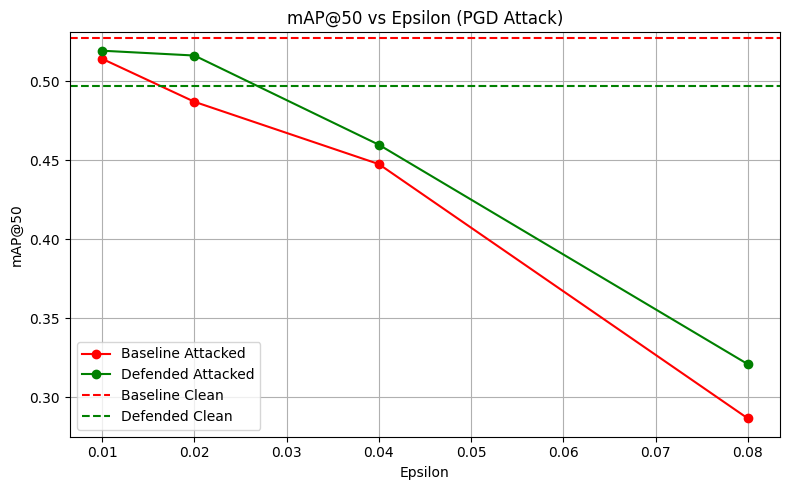

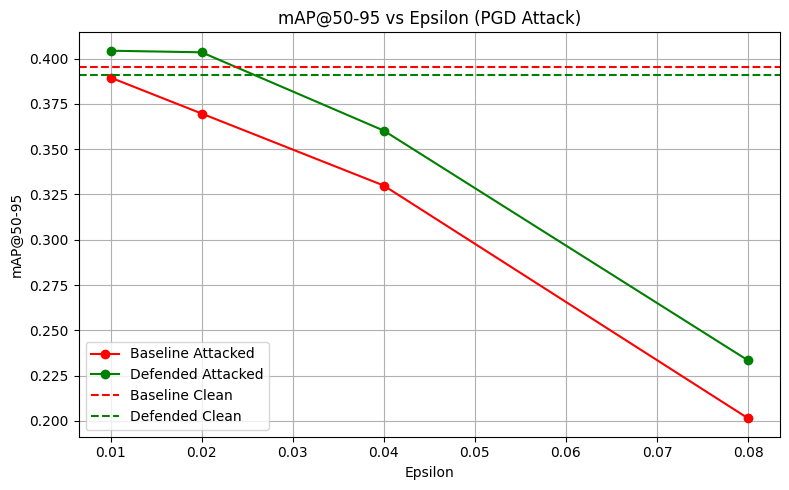

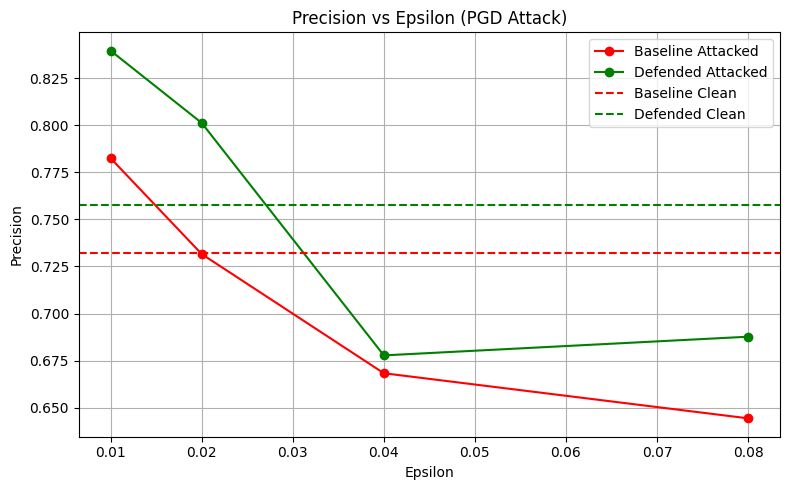

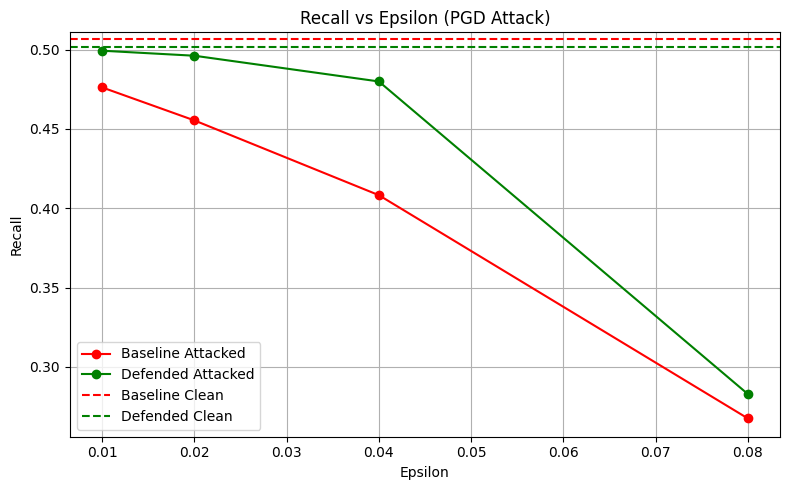

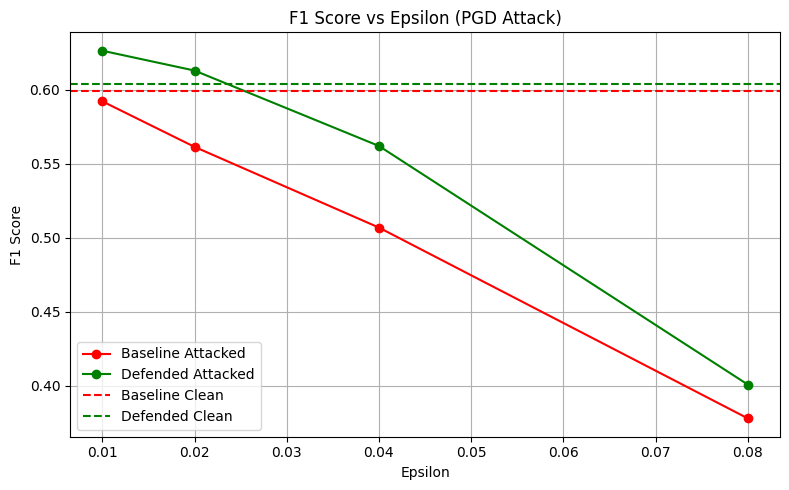

In [6]:
# Clean working directory
shutil.rmtree(WORK_DIR, ignore_errors=True)
os.makedirs(WORK_DIR, exist_ok=True)

# Load all three model instances
print("Loading models...")
base_attack = YOLO(BASELINE_MODEL_PATH)
base_eval   = YOLO(BASELINE_MODEL_PATH)
def_eval    = YOLO(DEFENDED_MODEL_PATH)

# Assign correct class names to all models
for m in [base_attack, base_eval, def_eval]:
    if hasattr(m.model, 'names'):
        m.model.names = CLASS_NAMES

# Sample images and run evaluation
sample_imgs = get_sample()
print(f"Evaluating on {len(sample_imgs)} images...")

metrics = evaluate(sample_imgs)